# Spam Detection — EDA & Tiền xử lý dữ liệu
**Thành viên:** B — Kỹ thuật dữ liệu  
**Tuần 1:** Thu thập, làm sạch, TF-IDF vectorization, phân tích EDA  
**Dataset:** SMS Spam Collection (Kaggle)

## 1. Import thư viện

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer
import joblib
import warnings
warnings.filterwarnings('ignore')

# Cấu hình hiển thị biểu đồ
plt.rcParams['figure.figsize'] = (8, 4)
plt.rcParams['font.size'] = 12
sns.set_theme(style='whitegrid')

## 2. Tải và kiểm tra dữ liệu gốc

In [2]:
df = pd.read_csv("spam.csv", encoding="latin-1")
df = df[['v1', 'v2']]
df.columns = ['label', 'text']
print(f"Shape: {df.shape}")
df.head()

Shape: (5572, 2)


,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [3]:
# Kiểm tra giá trị null và duplicate
print("=== Null values ===")
print(df.isnull().sum())
print(f"\n=== Duplicate rows: {df.duplicated().sum()} ===")

=== Null values ===
label    0
text     0
dtype: int64

=== Duplicate rows: 403 ===


## 3. Làm sạch dữ liệu

In [4]:
# Xóa duplicate
df = df.drop_duplicates()
print(f"Sau khi xóa duplicate: {df.shape[0]} dòng")

# Map nhãn sang 0/1
df["label"] = df["label"].map({"ham": 0, "spam": 1})

# Hàm làm sạch text
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = text.strip()
    return text

df["clean_text"] = df["text"].apply(clean_text)

# Xử lý các dòng clean_text rỗng hoặc null
null_count = df["clean_text"].isnull().sum()
empty_count = (df["clean_text"].str.strip() == "").sum()
print(f"Null trong clean_text: {null_count}")
print(f"Rỗng trong clean_text: {empty_count}")

df = df[df["clean_text"].notna() & (df["clean_text"].str.strip() != "")]
print(f"Sau khi xử lý null/rỗng: {df.shape[0]} dòng")
df.head()

Sau khi xóa duplicate: 5169 dòng
Null trong clean_text: 0
Rỗng trong clean_text: 3
Sau khi xử lý null/rỗng: 5166 dòng


,label,text,clean_text
0,0,"Go until jurong point, crazy.. Available only ...",go until jurong point crazy available only in ...
1,0,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in a wkly comp to win fa cup final...
3,0,U dun say so early hor... U c already then say...,u dun say so early hor u c already then say
4,0,"Nah I don't think he goes to usf, he lives aro...",nah i dont think he goes to usf he lives aroun...


## 4. Phân tích EDA

### 4.1 Phân phối nhãn spam / ham

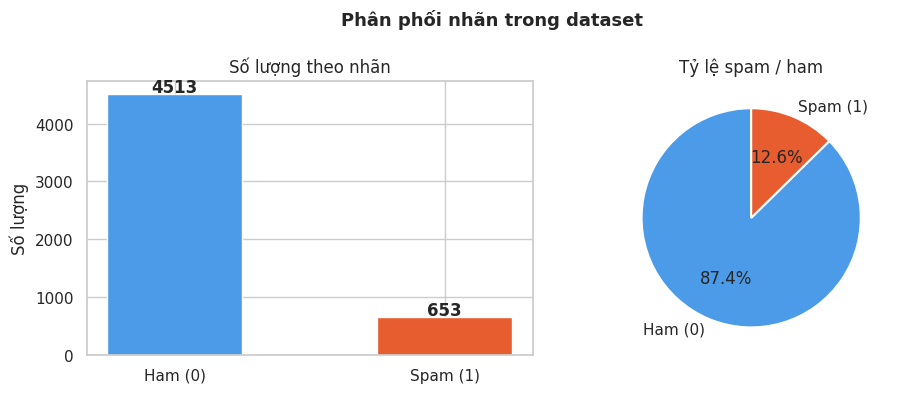

label
0    4513
1     653
Name: count, dtype: int64


In [5]:
counts = df["label"].value_counts()
labels_name = ["Ham (0)", "Spam (1)"]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Bar chart
axes[0].bar(labels_name, counts.values, color=["#4C9BE8", "#E85D30"], width=0.5, edgecolor='white')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 30, str(v), ha='center', fontweight='bold')
axes[0].set_title("Số lượng theo nhãn")
axes[0].set_ylabel("Số lượng")

# Pie chart
axes[1].pie(counts.values, labels=labels_name, autopct='%1.1f%%',
            colors=["#4C9BE8", "#E85D30"], startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title("Tỷ lệ spam / ham")

plt.suptitle("Phân phối nhãn trong dataset", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("plot_label_distribution.png", dpi=150, bbox_inches='tight')
plt.show()
print(counts)

### 4.2 Phân phối độ dài văn bản

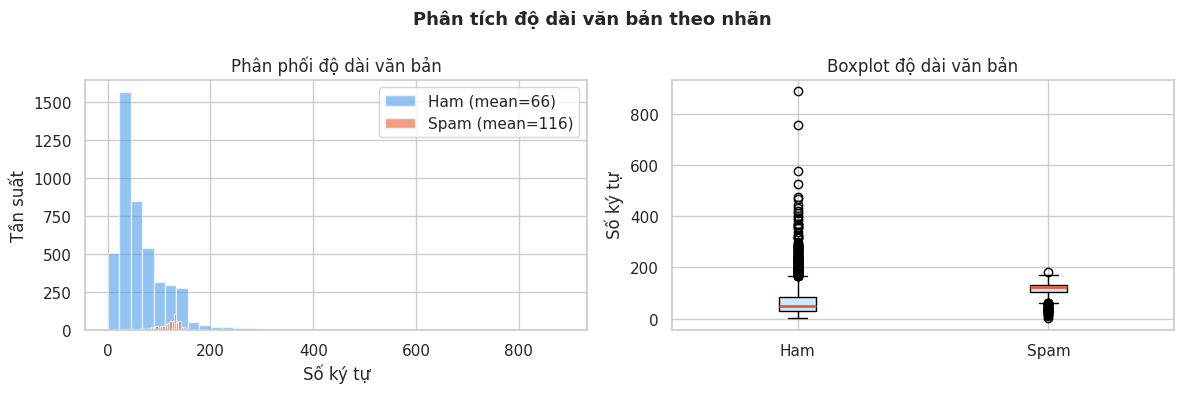

        count   mean   std  min    25%    50%    75%    max
label                                                      
0      4513.0   66.1  53.4  1.0   31.0   49.0   85.0  888.0
1       653.0  115.6  27.3  3.0  105.0  124.0  133.0  183.0


In [6]:
df["length"] = df["clean_text"].apply(len)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram phân theo nhãn
for label, color, name in [(0, "#4C9BE8", "Ham"), (1, "#E85D30", "Spam")]:
    subset = df[df["label"] == label]["length"]
    axes[0].hist(subset, bins=40, alpha=0.6, color=color, label=f"{name} (mean={subset.mean():.0f})")
axes[0].set_title("Phân phối độ dài văn bản")
axes[0].set_xlabel("Số ký tự")
axes[0].set_ylabel("Tần suất")
axes[0].legend()

# Boxplot
spam_len = df[df["label"] == 1]["length"]
ham_len  = df[df["label"] == 0]["length"]
axes[1].boxplot([ham_len, spam_len], labels=["Ham", "Spam"],
                patch_artist=True,
                boxprops=dict(facecolor="#D0E8FF"),
                medianprops=dict(color="#E85D30", linewidth=2))
axes[1].set_title("Boxplot độ dài văn bản")
axes[1].set_ylabel("Số ký tự")

plt.suptitle("Phân tích độ dài văn bản theo nhãn", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("plot_text_length.png", dpi=150, bbox_inches='tight')
plt.show()
print(df.groupby("label")["length"].describe().round(1))

### 4.3 WordCloud — Top từ phổ biến

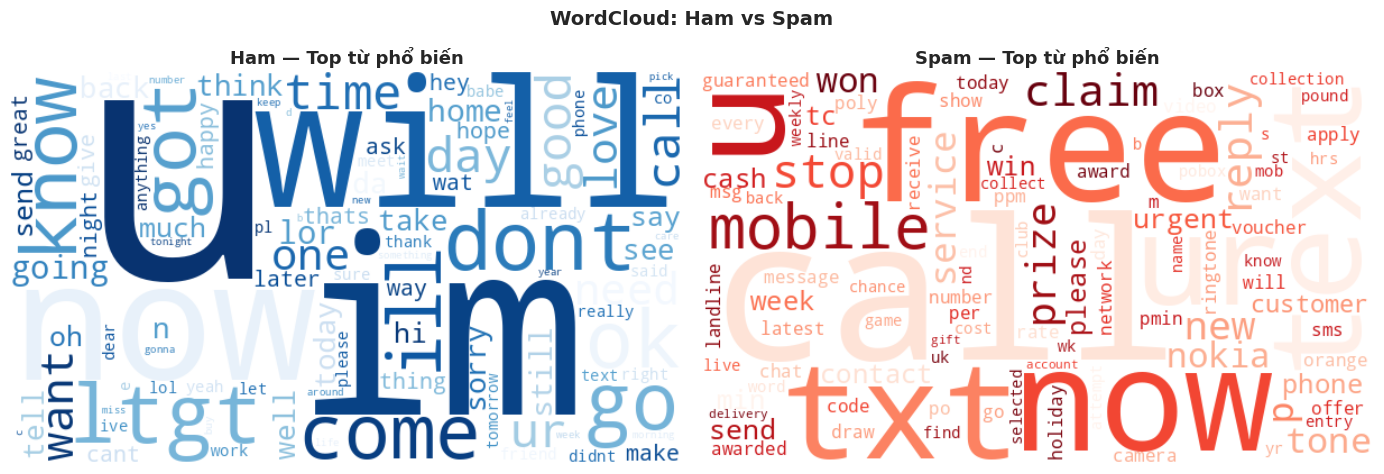

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, label, title, colormap in [
    (axes[0], 0, "Ham — Top từ phổ biến", "Blues"),
    (axes[1], 1, "Spam — Top từ phổ biến", "Reds")
]:
    text_corpus = " ".join(df[df["label"] == label]["clean_text"])
    wc = WordCloud(
        width=600, height=350,
        background_color='white',
        colormap=colormap,
        max_words=100,
        collocations=False
    ).generate(text_corpus)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(title, fontsize=13, fontweight='bold')

plt.suptitle("WordCloud: Ham vs Spam", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("plot_wordcloud.png", dpi=150, bbox_inches='tight')
plt.show()

### 4.4 Top 20 từ xuất hiện nhiều nhất

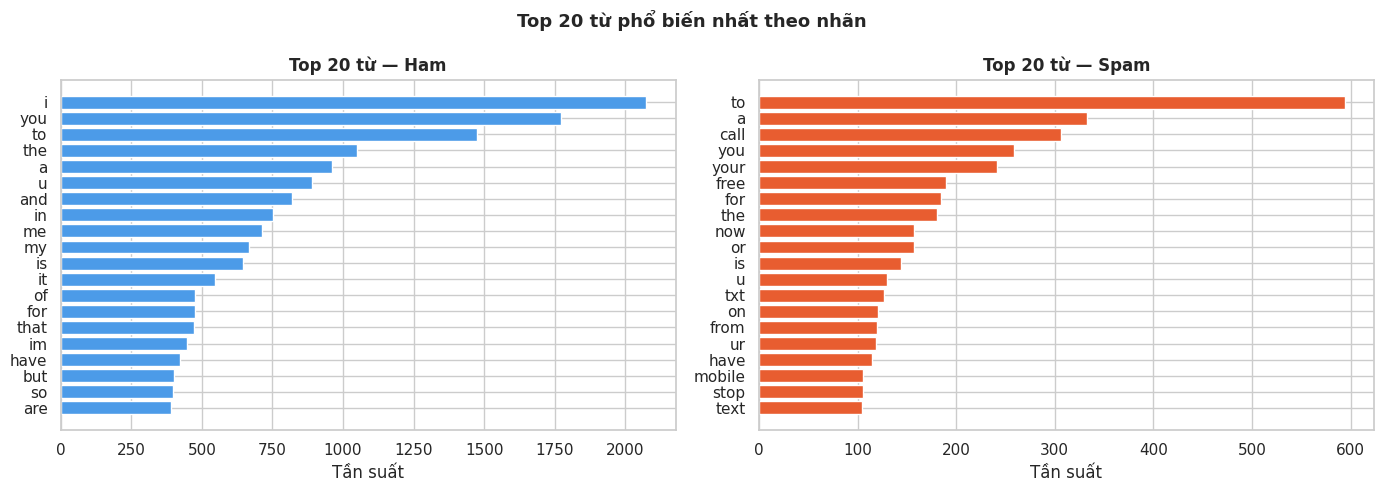

In [8]:
from collections import Counter

def get_top_words(df_subset, n=20):
    all_words = " ".join(df_subset["clean_text"]).split()
    return Counter(all_words).most_common(n)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, label, title, color in [
    (axes[0], 0, "Top 20 từ — Ham", "#4C9BE8"),
    (axes[1], 1, "Top 20 từ — Spam", "#E85D30")
]:
    top = get_top_words(df[df["label"] == label])
    words, freqs = zip(*top)
    ax.barh(words[::-1], freqs[::-1], color=color, edgecolor='white')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel("Tần suất")

plt.suptitle("Top 20 từ phổ biến nhất theo nhãn", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("plot_top20_words.png", dpi=150, bbox_inches='tight')
plt.show()

## 5. TF-IDF Vectorization

In [9]:
vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(df["clean_text"])
y = df["label"]

print(f"Shape của ma trận TF-IDF: {X.shape}")
print(f"Số nhãn y: {len(y)}")

Shape của ma trận TF-IDF: (5166, 5000)
Số nhãn y: 5166


## 6. Lưu file đầu ra

In [10]:
# Lưu dataset sạch
df.to_csv("clean_spam_dataset.csv", index=False)
print("Đã lưu: clean_spam_dataset.csv")

# Lưu vectorizer để tái sử dụng ở Tuần 2
joblib.dump(vectorizer, "tfidf_vectorizer.pkl")
print("Đã lưu: tfidf_vectorizer.pkl")

# Kiểm tra file
import os
for f in ["clean_spam_dataset.csv", "tfidf_vectorizer.pkl"]:
    size = os.path.getsize(f) if os.path.exists(f) else 0
    print(f"  {f}: {size:,} bytes")

Đã lưu: clean_spam_dataset.csv
Đã lưu: tfidf_vectorizer.pkl
  clean_spam_dataset.csv: 823,464 bytes
  tfidf_vectorizer.pkl: 180,493 bytes
